### Notebook to test pooling of datasets from YAIB

### Imports

In [1]:
import os
import copy
import logging

import gin
import json
import hashlib
import pandas as pd
import polars as pl
from pathlib import Path
import pickle
from timeit import default_timer as timer
from sklearn.model_selection import StratifiedKFold, KFold, StratifiedShuffleSplit, ShuffleSplit
from icu_benchmarks.data.preprocessor import Preprocessor, PandasClassificationPreprocessor, PolarsClassificationPreprocessor
from icu_benchmarks.constants import RunMode
from icu_benchmarks.run_utils import check_required_keys
from icu_benchmarks.data.constants import DataSplit as Split, DataSegment as Segment, VarType as Var

from icu_benchmarks.data.split_process_data import *
from icu_benchmarks.cross_validation import execute_repeated_cv  # adjust if path is different
from icu_benchmarks.run import *


In [2]:
vars_dict = {
    "GROUP": "stay_id",
    "SEQUENCE": "time",
    "LABEL": "label",
    "DYNAMIC": ["alb", "alp", "alt", "ast", "be", "bicar", "bili", "bili_dir", "bnd", "bun", "ca", "cai", "ck", "ckmb", "cl",
        "crea", "crp", "dbp", "fgn", "fio2", "glu", "hgb", "hr", "inr_pt", "k", "lact", "lymph", "map", "mch", "mchc", "mcv",
        "methb", "mg", "na", "neut", "o2sat", "pco2", "ph", "phos", "plt", "po2", "ptt", "resp", "sbp", "temp", "tnt", "urine",
        "wbc"],
    "STATIC": ["age", "sex", "height", "weight"],
}

# Load the gin config
gin.parse_config_file("/work3/s185395/YAIB/configs/tasks/Regression.gin")


/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


ParsedConfigFileIncludesAndImports(filename='/work3/s185395/YAIB/configs/tasks/Regression.gin', imports=[], includes=[ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/Imports.gin', imports=['icu_benchmarks.data.split_process_data', 'icu_benchmarks.data.loader', 'icu_benchmarks.models.wrappers', 'icu_benchmarks.models.dl_models', 'icu_benchmarks.models.ml_models'], includes=[]), ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/PredictionTaskVariables.gin', imports=[], includes=[]), ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/CrossValidation.gin', imports=[], includes=[]), ParsedConfigFileIncludesAndImports(filename='configs/tasks/common/Dataloader.gin', imports=[], includes=[])])

### Pool

In [ ]:


# Call the preprocessing function with the new scale
mimic = preprocess_data(
    data_dir=Path("/work3/s185395/YAIB-cohorts/data/los/mimic"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.regression
)

# Call the preprocessing function with the new scale
miiv = preprocess_data(
    data_dir=Path("/work3/s185395/YAIB-cohorts/data/los/miiv"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.regression
)

# Call the preprocessing function with the new scale
eicu = preprocess_data(
    data_dir=Path("/work3/s185395/YAIB-cohorts/data/los/eicu"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.regression
)


/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


KeyError: 'OUTCOME'
  In call to configurable 'preprocess' (<function preprocess_data at 0x7f8057fe7010>)

In [4]:
print(type(mimic['train']['FEATURES']))
print(mimic['train']['FEATURES'].columns)

<class 'polars.dataframe.frame.DataFrame'>
['stay_id', 'time', 'alb', 'alp', 'alt', 'ast', 'be', 'bicar', 'bili', 'bili_dir', 'bnd', 'bun', 'ca', 'cai', 'ck', 'ckmb', 'cl', 'crea', 'crp', 'dbp', 'fgn', 'fio2', 'glu', 'hgb', 'hr', 'inr_pt', 'k', 'lact', 'lymph', 'map', 'mch', 'mchc', 'mcv', 'methb', 'mg', 'na', 'neut', 'o2sat', 'pco2', 'ph', 'phos', 'plt', 'po2', 'ptt', 'resp', 'sbp', 'temp', 'tnt', 'urine', 'wbc', 'MissingIndicator_alb', 'MissingIndicator_alp', 'MissingIndicator_alt', 'MissingIndicator_ast', 'MissingIndicator_be', 'MissingIndicator_bicar', 'MissingIndicator_bili', 'MissingIndicator_bili_dir', 'MissingIndicator_bnd', 'MissingIndicator_bun', 'MissingIndicator_ca', 'MissingIndicator_cai', 'MissingIndicator_ck', 'MissingIndicator_ckmb', 'MissingIndicator_cl', 'MissingIndicator_crea', 'MissingIndicator_crp', 'MissingIndicator_dbp', 'MissingIndicator_fgn', 'MissingIndicator_fio2', 'MissingIndicator_glu', 'MissingIndicator_hgb', 'MissingIndicator_hr', 'MissingIndicator_inr_pt

In [5]:
eicu['train']['FEATURES'].columns == miiv['train']['FEATURES'].columns

True

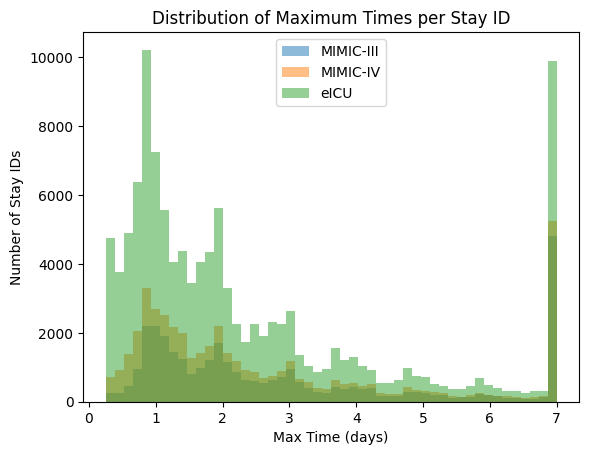

In [16]:
import polars as pl
import matplotlib.pyplot as plt

def get_max_time_days(df):
    return (
        df.group_by('stay_id')
          .agg(pl.col('time').max().alias('max_time'))
          .with_columns(
              pl.col('max_time').map_elements(lambda x: x.total_seconds() / 86400, return_dtype=pl.Float64).alias('max_time_days')
          )
          .to_pandas()
    )

# Extract max time in days for both dataframes
mimic_days = get_max_time_days(mimic['train']['OUTCOME'])
miiv_days = get_max_time_days(miiv['train']['OUTCOME'])
eicu_days = get_max_time_days(eicu['train']['OUTCOME'])

# Plot both histograms on the same figure
plt.hist(mimic_days['max_time_days'], bins=50, alpha=0.5, label='MIMIC-III')
plt.hist(miiv_days['max_time_days'], bins=50, alpha=0.5, label='MIMIC-IV')
plt.hist(eicu_days['max_time_days'], bins=50, alpha=0.5, label='eICU')

plt.xlabel("Max Time (days)")
plt.ylabel("Number of Stay IDs")
plt.title("Distribution of Maximum Times per Stay ID")
plt.legend()
plt.show()

In [70]:
from pathlib import Path
import logging
import pandas as pd
from sklearn.model_selection import train_test_split
from icu_benchmarks.data.constants import DataSegment as Segment, VarType as Var
from icu_benchmarks.constants import RunMode
import pyarrow.parquet as pq

class PooledDataset:
    hirid_eicu_miiv = ["hirid", "eicu", "miiv"]
    aumc_hirid_eicu = ["aumc", "hirid", "eicu"]
    aumc_eicu_miiv = ["aumc", "eicu", "miiv"]
    aumc_hirid_miiv = ["aumc", "hirid", "miiv"]
    aumc_hirid_eicu_miiv = ["aumc", "hirid", "eicu", "miiv"]
    eicu_miiv = ["eicu", "miiv"]
    eicu_miiv_mimic = ["eicu", "miiv", "mimic"]


class PooledData:
    def __init__(
        self,
        data_dir,
        vars_dict,
        datasets,
        file_names,
        shuffle=False,
        stratify=None,
        runmode=RunMode.classification,
        save_test=True,
    ):
        self.data_dir = data_dir
        self.vars_dict = vars_dict  # ✅ store as vars_dict
        self.datasets = datasets
        self.file_names = file_names
        self.shuffle = shuffle
        self.stratify = stratify
        self.runmode = runmode
        self.save_test = save_test

    def generate(self, datasets, samples=10000, seed=42):
        data = {}
        for folder in self.data_dir.iterdir():
            if folder.is_dir() and folder.name in datasets:
                data[folder.name] = {
                    f: pq.read_table(folder / self.file_names[f]).to_pandas(self_destruct=True)
                    for f in self.file_names
                }
        data = self._pool_datasets(
            datasets=data,
            samples=samples,
            vars_dict=self.vars_dict,  # ✅ pass it correctly
            shuffle=self.shuffle,
            seed=seed,
            runmode=self.runmode,
            data_dir=self.data_dir,
            save_test=self.save_test,
        )
        self._save_pooled_data(self.data_dir, data, datasets, self.file_names, samples=samples)

    def _save_pooled_data(self, data_dir, data, datasets, file_names, samples=10000):
        save_folder = "_".join(datasets) + f"_{samples}"
        save_dir = data_dir / save_folder
        if not save_dir.exists():
            save_dir.mkdir()
        for key, value in data.items():
            value.to_parquet(save_dir / Path(file_names[key]))
        logging.info(f"Saved pooled data at {save_dir}")

    def _pool_datasets(
        self,
        datasets=None,
        samples=10000,
        vars_dict=None,
        seed=42,
        shuffle=True,
        runmode=RunMode.classification,
        data_dir=Path("data"),
        save_test=True,
    ):
        if datasets is None:
            datasets = {}
        if vars_dict is None:
            vars_dict = {}
        if len(datasets) == 0:
            raise ValueError("No datasets supplied.")

        pooled_data = {
            Segment.static.lower(): [],
            Segment.dynamic.lower(): [],
            Segment.outcome.lower(): []
        }

        id_col = vars_dict[Var.group]
        int_id = 0

        for key, value in datasets.items():
            int_id += 1
            repeated_digit = str(int_id) * 4

            outcome_full = value[Segment.outcome.lower()]
            static_full = value[Segment.static.lower()]
            dynamic_full = value[Segment.dynamic.lower()]

            stays = pd.Series(outcome_full[id_col].unique())
            print(f"[{key}] Total stays: {len(stays)}")

            if samples is None:
                train_ids = stays
                test_ids = pd.Series([], dtype=stays.dtype)
                print(f"[{key}] Using all {len(train_ids)} stays (no test split)")
            else:
                if runmode is RunMode.classification:
                    labels = outcome_full.groupby(id_col).max()[vars_dict[Var.label]].reset_index(drop=True)
                    train_ids, test_ids = train_test_split(
                        stays, stratify=labels, shuffle=shuffle, random_state=seed, train_size=samples
                    )
                else:
                    train_ids, test_ids = train_test_split(
                        stays, shuffle=shuffle, random_state=seed, train_size=samples
                    )

            # Handle test set first, only if sampling
            if save_test and samples is not None:
                outcome_test, static_test, dynamic_test = self._select_stays(
                    outcome_full.copy(), static_full.copy(), dynamic_full.copy(),
                    test_ids, id_col, repeated_digit
                )
                save_folder = key + f"_test_{len(test_ids)}"
                save_dir = data_dir / save_folder
                save_dir.mkdir(exist_ok=True)
                outcome_test.to_parquet(save_dir / Path("outc.parquet"))
                static_test.to_parquet(save_dir / Path("sta.parquet"))
                dynamic_test.to_parquet(save_dir / Path("dyn.parquet"))
                logging.info(f"Saved test data at {save_dir}")

            # Now handle training stays
            outcome_train, static_train, dynamic_train = self._select_stays(
                outcome_full.copy(), static_full.copy(), dynamic_full.copy(),
                train_ids, id_col, repeated_digit
            )

            pooled_data[Segment.static.lower()].append(static_train)
            pooled_data[Segment.dynamic.lower()].append(dynamic_train)
            pooled_data[Segment.outcome.lower()].append(outcome_train)

        for key in pooled_data:
            pooled_data[key] = pd.concat(pooled_data[key], ignore_index=True)

        return pooled_data


    def _select_stays(self, outcome, static, dynamic, select, id_col, repeated_digit=1):
        print(f"[Select] Matching {len(select)} stays in outcome shape {outcome.shape}")
        matched = outcome[outcome[id_col].isin(select)]
        print(f"[Select] Found {len(matched)} matching rows before ID modification")
        
        outcome = outcome.loc[outcome[id_col].isin(select)]
        static = static.loc[static[id_col].isin(select)]
        dynamic = dynamic.loc[dynamic[id_col].isin(select)]

        outcome[id_col] = outcome[id_col].map(lambda x: int(str(x) + repeated_digit))
        static[id_col] = static[id_col].map(lambda x: int(str(x) + repeated_digit))
        dynamic[id_col] = dynamic[id_col].map(lambda x: int(str(x) + repeated_digit))
        return outcome, static, dynamic


In [72]:
from pathlib import Path
#from icu_benchmarks.data.pooling import PooledData, PooledDataset
from icu_benchmarks.constants import RunMode
import logging

logging.basicConfig(level=logging.INFO)

file_names = {
    "outcome": "outc.parquet",
    "static": "sta.parquet",
    "dynamic": "dyn.parquet"
}

def generate_pooled_data(data_dir, vars_dict, datasets, file_names, seed, runmode):
    pooled = PooledData(
        data_dir=data_dir,
        vars_dict=vars_dict,  # ✅ renamed
        datasets=datasets,
        file_names=file_names,
        runmode=runmode,
    )
    pooled.generate(datasets=datasets, samples=None, seed=seed)


Datasets = [
    PooledDataset.eicu_miiv,
]

seed = 42
runmode = RunMode.regression

for item in Datasets:
    generate_pooled_data(
        Path("/work3/s185395/YAIB-cohorts/data/los"),
        vars_dict=vars_dict,
        datasets=item,
        file_names=file_names,
        seed=seed,
        runmode=runmode
    )


[miiv] Total stays: 71962
[miiv] Using all 71962 stays (no test split)
[Select] Matching 71962 stays in outcome shape (4719995, 3)
[Select] Found 4719995 matching rows before ID modification
[eicu] Total stays: 182788
[eicu] Using all 182788 stays (no test split)
[Select] Matching 182788 stays in outcome shape (10670965, 3)
[Select] Found 10670965 matching rows before ID modification


### Load in pool data

In [3]:
from pathlib import Path
import pandas as pd

path = Path("/work3/s185395/YAIB-cohorts/data/los/eicu_miiv_None")
for name in ["outc.parquet", "sta.parquet", "dyn.parquet"]:
    f = path / name
    print(f"{f}: exists = {f.exists()}, size = {f.stat().st_size if f.exists() else 0}")


/work3/s185395/YAIB-cohorts/data/los/eicu_miiv_None/outc.parquet: exists = True, size = 5353929
/work3/s185395/YAIB-cohorts/data/los/eicu_miiv_None/sta.parquet: exists = True, size = 2736529
/work3/s185395/YAIB-cohorts/data/los/eicu_miiv_None/dyn.parquet: exists = True, size = 169788532


In [4]:
outc = pd.read_parquet(path / "dyn.parquet")
print("Rows:", len(outc))
print("Columns:", outc.columns)
print(outc.head())


Rows: 15390960
Columns: Index(['stay_id', 'time', 'alb', 'alp', 'alt', 'ast', 'be', 'bicar', 'bili',
       'bili_dir', 'bnd', 'bun', 'ca', 'cai', 'ck', 'ckmb', 'cl', 'crea',
       'crp', 'dbp', 'fgn', 'fio2', 'glu', 'hgb', 'hr', 'inr_pt', 'k', 'lact',
       'lymph', 'map', 'mch', 'mchc', 'mcv', 'methb', 'mg', 'na', 'neut',
       'o2sat', 'pco2', 'ph', 'phos', 'plt', 'po2', 'ptt', 'resp', 'sbp',
       'temp', 'tnt', 'urine', 'wbc'],
      dtype='object')
        stay_id            time  alb  alp  alt  ast   be  bicar  bili  \
0  300001531111 0 days 00:00:00  NaN  NaN  NaN  NaN  NaN    NaN   NaN   
1  300001531111 0 days 01:00:00  NaN  NaN  NaN  NaN -3.0    NaN   NaN   
2  300001531111 0 days 02:00:00  NaN  NaN  NaN  NaN  NaN    NaN   NaN   
3  300001531111 0 days 03:00:00  NaN  NaN  NaN  NaN -4.0   19.0   NaN   
4  300001531111 0 days 04:00:00  NaN  NaN  NaN  NaN  NaN    NaN   NaN   

   bili_dir  ...  phos    plt    po2   ptt  resp    sbp       temp  tnt  \
0       NaN  ...   NaN 

In [5]:
len(outc['stay_id'].unique())

254750

In [4]:
# Call the preprocessing function with the new scale
data = preprocess_data(
    data_dir=Path("/work3/s185395/YAIB-cohorts/data/los/eicu_miiv_None"),
    #data_dir=Path("/work3/s185395/YAIB-cohorts/data/mortality24/mimic"),
    seed=2222,
    generate_cache=True,
    load_cache=False,
    debug=False,
    use_static = True,
    runmode=RunMode.regression
)

In [7]:
data['train']['FEATURES'].head()

stay_id,time,alb,alp,alt,ast,be,bicar,bili,bili_dir,bnd,bun,ca,cai,ck,ckmb,cl,crea,crp,dbp,fgn,fio2,glu,hgb,hr,inr_pt,k,lact,lymph,map,mch,mchc,mcv,methb,mg,na,neut,…,MissingIndicator_fio2,MissingIndicator_glu,MissingIndicator_hgb,MissingIndicator_hr,MissingIndicator_inr_pt,MissingIndicator_k,MissingIndicator_lact,MissingIndicator_lymph,MissingIndicator_map,MissingIndicator_mch,MissingIndicator_mchc,MissingIndicator_mcv,MissingIndicator_methb,MissingIndicator_mg,MissingIndicator_na,MissingIndicator_neut,MissingIndicator_o2sat,MissingIndicator_pco2,MissingIndicator_ph,MissingIndicator_phos,MissingIndicator_plt,MissingIndicator_po2,MissingIndicator_ptt,MissingIndicator_resp,MissingIndicator_sbp,MissingIndicator_temp,MissingIndicator_tnt,MissingIndicator_urine,MissingIndicator_wbc,age,sex,height,weight,MissingIndicator_age,MissingIndicator_sex,MissingIndicator_height,MissingIndicator_weight
i64,duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,i64,f64,f64,bool,bool,bool,bool
2133962222,3d 1h,0.0,0.0,0.0,0.0,0.439374,0.913662,0.0,0.0,0.0,-0.686918,0.279875,0.0,0.0,0.0,-0.490859,-0.487882,0.0,-1.002574,-0.328985,2.790525,-0.284922,-0.068769,-0.616967,-0.639811,-0.089817,0.0,1.300609,-0.31512,0.655765,-0.035759,0.783579,0.0,0.0,-0.154345,-1.324753,…,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,true,true,true,true,0.520255,1,0.495772,0.046693,false,false,false,false
10743922222,3d,1.101605,-0.25279,0.186228,-0.151929,0.0,0.531032,0.018244,-0.265453,0.0,4.966225,-1.212895,0.0,0.0,0.0,-3.368921,2.083654,0.0,-0.430315,0.0,0.0,1.245229,1.030511,0.219736,-0.112969,-1.024625,-0.034442,-0.729906,-1.183324,1.361919,0.932913,0.944452,0.0,0.663071,-1.833116,0.868279,…,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,false,true,false,true,0.63839,1,0.495772,1.462545,false,false,false,false
12295172222,3h,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.699613,0.0,-0.397895,0.0,0.0,0.777538,0.0,0.0,0.0,0.0,-0.873251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,false,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,true,true,true,true,0.93373,1,0.702394,-0.419984,false,false,false,false
30290862222,4d 15h,-0.37937,0.0,0.0,0.0,0.439374,-0.425544,0.0,0.0,0.0,0.101893,-0.46651,0.0,-0.162631,0.0,0.660365,0.027747,0.0,-0.093693,0.0,-0.929298,0.073199,-0.833485,-0.254396,-0.534443,-1.024625,0.0,0.0,1.297259,-0.325003,-0.100338,-0.313282,0.0,-1.42561,0.68504,0.0,…,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,true,true,true,true,1.347206,1,0.280885,-0.03636,false,false,false,false
31927682222,2d 19h,0.0,0.0,0.0,0.0,-0.08658,-0.042914,0.0,0.0,0.0,-0.643095,0.52867,0.0,0.0,0.0,-0.778666,-0.692812,0.0,0.24293,0.0,-0.610456,-0.577929,1.1261,-0.895868,0.0,0.377588,0.0,-0.256119,0.646106,-0.560388,-0.100338,-0.576529,0.0,-0.90344,-0.322222,0.278901,…,true,false,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,true,true,true,false,false,true,true,false,true,-0.011357,1,0.702394,-0.325067,false,false,false,false


In [12]:
import polars as pl

df = data['train']['FEATURES']

# Step 1: Get unique stay_ids
unique_stays = df.select(pl.col("stay_id").unique())

# Step 2: Extract dataset identifier from last 4 digits
unique_stays = unique_stays.with_columns(
    pl.col("stay_id").cast(pl.Utf8).str.slice(-4).alias("dataset")
)

# Step 3: Count how many stay_ids per dataset
dataset_counts = unique_stays.group_by("dataset").agg(
    pl.count().alias("count")
)

# Step 4: Calculate percentage
total_unique = unique_stays.height
dataset_counts = dataset_counts.with_columns(
    (pl.col("count") / total_unique * 100).alias("percent")
)

print(dataset_counts)

shape: (2, 3)
┌─────────┬────────┬───────────┐
│ dataset ┆ count  ┆ percent   │
│ ---     ┆ ---    ┆ ---       │
│ str     ┆ u32    ┆ f64       │
╞═════════╪════════╪═══════════╡
│ 2222    ┆ 116740 ┆ 71.602061 │
│ 1111    ┆ 46300  ┆ 28.397939 │
└─────────┴────────┴───────────┘


/tmp/ipykernel_1331809/496989706.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("count")


In [87]:
import polars as pl

df = data['val']['FEATURES']

# Step 1: Get unique stay_ids
unique_stays = df.select(pl.col("stay_id").unique())

# Step 2: Extract dataset identifier from last 4 digits
unique_stays = unique_stays.with_columns(
    pl.col("stay_id").cast(pl.Utf8).str.slice(-4).alias("dataset")
)

# Step 3: Count how many stay_ids per dataset
dataset_counts = unique_stays.group_by("dataset").agg(
    pl.count().alias("count")
)

# Step 4: Calculate percentage
total_unique = unique_stays.height
dataset_counts = dataset_counts.with_columns(
    (pl.col("count") / total_unique * 100).alias("percent")
)

print(dataset_counts)

shape: (2, 3)
┌─────────┬───────┬───────────┐
│ dataset ┆ count ┆ percent   │
│ ---     ┆ ---   ┆ ---       │
│ str     ┆ u32   ┆ f64       │
╞═════════╪═══════╪═══════════╡
│ 2222    ┆ 29222 ┆ 71.692836 │
│ 1111    ┆ 11538 ┆ 28.307164 │
└─────────┴───────┴───────────┘


/tmp/ipykernel_1207071/4016841395.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("count")


In [ ]:
import polars as pl

df = data['test']['FEATURES']

# Step 1: Get unique stay_ids
unique_stays = df.select(pl.col("stay_id").unique())

# Step 2: Extract dataset identifier from last 4 digits
unique_stays = unique_stays.with_columns(
    pl.col("stay_id").cast(pl.Utf8).str.slice(-4).alias("dataset")
)

# Step 3: Count how many stay_ids per dataset
dataset_counts = unique_stays.group_by("dataset").agg(
    pl.count().alias("count")
)

# Step 4: Calculate percentage
total_unique = unique_stays.height
dataset_counts = dataset_counts.with_columns(
    (pl.col("count") / total_unique * 100).alias("percent")
)

print(dataset_counts)

shape: (2, 3)
┌─────────┬───────┬───────────┐
│ dataset ┆ count ┆ percent   │
│ ---     ┆ ---   ┆ ---       │
│ str     ┆ u32   ┆ f64       │
╞═════════╪═══════╪═══════════╡
│ 2222    ┆ 36826 ┆ 72.278705 │
│ 1111    ┆ 14124 ┆ 27.721295 │
└─────────┴───────┴───────────┘


/tmp/ipykernel_1207071/3301627731.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("count")


### Reduce dimensions of data

In [5]:
df = data['train']['FEATURES']

# Convert stay_id to string and extract last 4 digits to determine group
# Correct use of `pl.when(...).then(...).otherwise(...)`
df = df.with_columns([
    pl.when(pl.col("stay_id").cast(pl.Utf8).str.ends_with("2222"))
      .then(pl.lit("eICU"))
      .when(pl.col("stay_id").cast(pl.Utf8).str.ends_with("1111"))
      .then(pl.lit("MIMIC-IV"))
      .otherwise(pl.lit("UNKNOWN"))
      .alias("group")
])

print(df.head())


shape: (5, 107)
┌────────────┬────────────┬───────────┬───────────┬───┬────────────┬───────────┬───────────┬───────┐
│ stay_id    ┆ time       ┆ alb       ┆ alp       ┆ … ┆ MissingInd ┆ MissingIn ┆ MissingIn ┆ group │
│ ---        ┆ ---        ┆ ---       ┆ ---       ┆   ┆ icator_sex ┆ dicator_h ┆ dicator_w ┆ ---   │
│ i64        ┆ duration[m ┆ f64       ┆ f64       ┆   ┆ ---        ┆ eight     ┆ eight     ┆ str   │
│            ┆ s]         ┆           ┆           ┆   ┆ bool       ┆ ---       ┆ ---       ┆       │
│            ┆            ┆           ┆           ┆   ┆            ┆ bool      ┆ bool      ┆       │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪════════════╪═══════════╪═══════════╪═══════╡
│ 2482556222 ┆ 9h         ┆ -0.083175 ┆ 0.42189   ┆ … ┆ false      ┆ false     ┆ false     ┆ eICU  │
│ 2          ┆            ┆           ┆           ┆   ┆            ┆           ┆           ┆       │
│ 2716228222 ┆ 4d 23h     ┆ -2.304637 ┆ 0.329122  ┆ … ┆ false      ┆ false 

In [ ]:
import pandas as pd 

df_pd = df.to_pandas()
# List of numeric columns for t-SNE
dynamic_columns = vars_dict['DYNAMIC']

# Drop rows with missing data
df_clean = df_pd.dropna(subset=dynamic_columns + ['group'])

# Sample 1000 rows randomly
n = len(df_pd)
df_sample = df_clean.sample(n=n, random_state=42)

import umap
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)  # X_scaled from earlier



In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import umap

df_pd = df.to_pandas()
# List of numeric columns for t-SNE
dynamic_columns = vars_dict['DYNAMIC']

# Drop rows with missing data
df_clean = df_pd.dropna(subset=dynamic_columns + ['group'])

# Sample 1000 rows randomly
#n = len(df_pd)
n = 100000
df_sample = df_clean.sample(n=n, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[dynamic_columns])

# Perform PCA
#pca = PCA(n_components=2)
#pca_result = pca.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2, random_state=42)
umap_result = reducer.fit_transform(X_scaled)  # X_scaled from earlier
# Standardize features before PCA
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(df_clean[dynamic_columns])

# Run PCA
#pca = PCA(n_components=2)
#pca_result = pca.fit_transform(X_scaled)

/work3/s185395/YAIB/yaib_venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


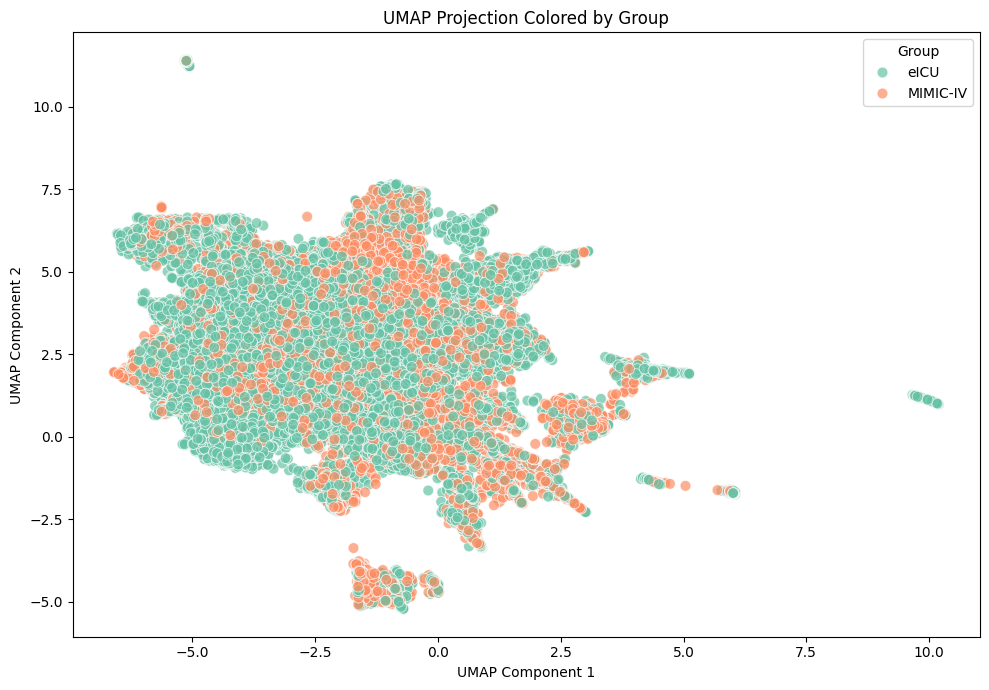

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame for plotting
umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['group'] = df_sample['group'].values  # Add your labels (e.g., "eICU", "MIMIC-IV")

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='group',
    palette='Set2',
    alpha=0.7,
    s=60
)
plt.title("UMAP Projection Colored by Group")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(title='Group')
plt.tight_layout()
plt.show()


# Testing chartevent load fail 

In [ ]:
import pandas as pd

breaks = [127, 210, 425, 549, 643, 741, 1483, 3458, 3695, 8440, 8553] #, 220274, 223921, 224085, 224859, 227629]


file_path = "/work3/s185395/YAIB-cohorts/data/mimic/CHARTEVENTS.csv.gz"

# Read a chunk
df = pd.read_csv(file_path, usecols=["ITEMID"])

itemids_in_file = df["ITEMID"].unique()

In [33]:
# Check which break ITEMIDs are missing
missing_breaks = [i for i in breaks if i not in itemids_in_file]

print("Break ITEMIDs missing from the file:", missing_breaks)

Break ITEMIDs missing from the file: [220274, 223921, 224085, 224859, 227629]


In [36]:
import numpy as np
breaks = [127, 210, 425, 549, 643, 741, 1483, 3458, 3695, 8440, 8553]

# Include lower and upper bounds to define partitions
partitions = list(zip([float('-inf')] + breaks, breaks + [float('inf')]))

# For each partition range, count how many itemids fall into it
for i, (low, high) in enumerate(partitions):
    count = ((df["ITEMID"] >= low) & (df["ITEMID"] < high)).sum()
    print(f"Partition {i+1}: ITEMID in [{low}, {high}) → {count} rows")


Partition 1: ITEMID in [-inf, 127) → 13738768 rows
Partition 2: ITEMID in [127, 210) → 14243117 rows
Partition 3: ITEMID in [210, 425) → 15812580 rows
Partition 4: ITEMID in [425, 549) → 14073515 rows
Partition 5: ITEMID in [549, 643) → 15984433 rows
Partition 6: ITEMID in [643, 741) → 12895331 rows
Partition 7: ITEMID in [741, 1483) → 15105582 rows
Partition 8: ITEMID in [1483, 3458) → 19511900 rows
Partition 9: ITEMID in [3458, 3695) → 19957792 rows
Partition 10: ITEMID in [3695, 8440) → 14199458 rows
Partition 11: ITEMID in [8440, 8553) → 14623493 rows
Partition 12: ITEMID in [8553, inf) → 2338089 rows


In [35]:
14623493 - 13738768

884725